# Communities and epidemic spreading

Two applied network-analysis studies with NetworkX: (1) modularity-based community detection on a corporate internal e-mail network, compared against the real departmental structure using Shannon entropy; (2) simulation of epidemic spreading on a US airport network, evaluating interventions — social distancing (edge removal) and random vs. hub-targeted vaccination (node removal).

*Analysis narrative is in Spanish (original coursework cells preserved as written).*

## Part 1: Corporate e-mail network — communities vs. departments

In [1]:
# Imports
import matplotlib.pyplot as plt
%matplotlib inline
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np
from collections import Counter
import math

In [2]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:

file_path = "/content/drive/MyDrive/data/"

# Cargamos los datos del archivo en un grafo de NetworkX
G = nx.read_edgelist(file_path+"mails.txt", nodetype=int)

# Calculamos las componentes del grafo
components = list(nx.connected_components(G))
number_of_components = len(components)
number_of_components

20

In [4]:
# Verificamos si la red es conexa (una sola componente) y, si no, encontramos la componente gigante
is_connected = nx.is_connected(G)
largest_component = max(components, key=len) if not is_connected else None
is_connected, largest_component

(False,
 {0,
  1,
  2,
  3,
  4,
  5,
  6,
  7,
  8,
  9,
  10,
  11,
  12,
  13,
  14,
  15,
  16,
  17,
  18,
  19,
  20,
  21,
  22,
  23,
  24,
  25,
  26,
  27,
  28,
  29,
  30,
  31,
  32,
  33,
  34,
  35,
  36,
  37,
  38,
  39,
  40,
  41,
  42,
  43,
  44,
  45,
  46,
  47,
  48,
  49,
  50,
  51,
  52,
  53,
  54,
  55,
  56,
  57,
  58,
  59,
  60,
  61,
  62,
  63,
  64,
  65,
  66,
  67,
  68,
  69,
  70,
  71,
  72,
  73,
  74,
  75,
  76,
  77,
  78,
  79,
  80,
  81,
  82,
  83,
  84,
  85,
  86,
  87,
  88,
  89,
  90,
  91,
  92,
  93,
  94,
  95,
  96,
  97,
  98,
  99,
  100,
  101,
  102,
  103,
  104,
  105,
  106,
  107,
  108,
  109,
  110,
  111,
  112,
  113,
  114,
  115,
  116,
  117,
  118,
  119,
  120,
  121,
  122,
  123,
  124,
  125,
  126,
  127,
  128,
  129,
  130,
  131,
  132,
  133,
  134,
  135,
  136,
  137,
  138,
  139,
  140,
  141,
  142,
  143,
  144,
  145,
  146,
  147,
  148,
  149,
  150,
  151,
  152,
  153,
  154,
  155,
  156,
  1

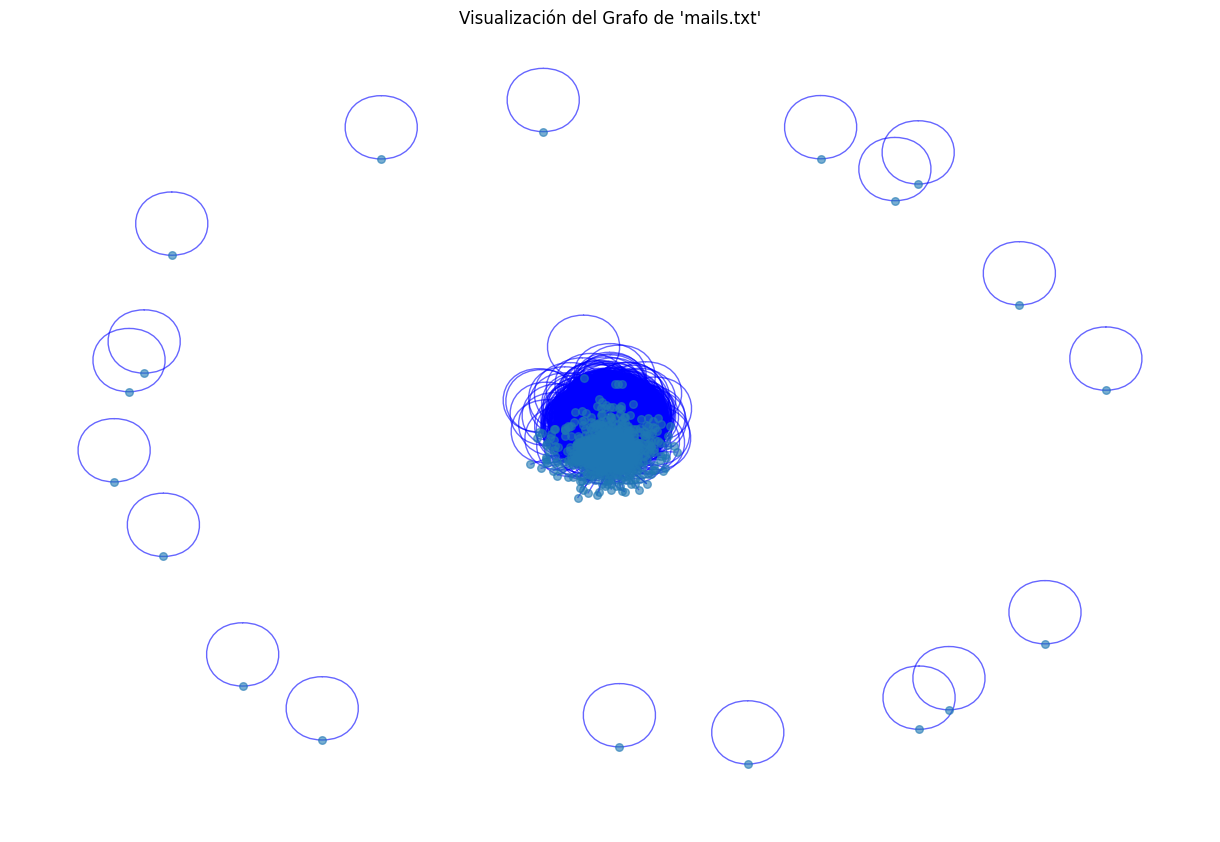

In [5]:
# Creación de una figura sencilla de la red
plt.figure(figsize=(12, 8))
nx.draw(G, with_labels=False, node_size=30, edge_color="blue", alpha=0.6)
plt.title("Visualización del Grafo de 'mails.txt'")
plt.show()

In [6]:
# Verificamos la existencia de self-loops
has_self_loops = nx.number_of_selfloops(G) > 0
has_self_loops

True

Hay 20 componentes diferentes en el grafo.

El grafo no es conexo, lo que significa que no todas las partes del grafo están interconectadas.

La componente más grande del grafo incluye una gran cantidad de nodos, lo que indica que es significativamente más grande que las otras componentes.

In [7]:
#ayuda
! pip install python-louvain

In [8]:
import networkx.algorithms.community as nx_comm

# Utilizamos el algoritmo de Louvain (aproximado por la función de NetworkX) para encontrar la partición que maximiza la modularidad
communities_generator = nx_comm.greedy_modularity_communities(G)
communities_list = [list(c) for c in communities_generator]

# Calculamos el número de comunidades y el tamaño de cada comunidad
number_of_communities = len(communities_list)
community_sizes = {f"Community {i+1}": len(comm) for i, comm in enumerate(communities_list)}

# Calculamos el valor de la modularidad
modularity = nx_comm.modularity(G, communities_generator)
number_of_communities, community_sizes, modularity

(44,
 {'Community 1': 368,
  'Community 2': 321,
  'Community 3': 103,
  'Community 4': 89,
  'Community 5': 58,
  'Community 6': 9,
  'Community 7': 9,
  'Community 8': 9,
  'Community 9': 2,
  'Community 10': 2,
  'Community 11': 2,
  'Community 12': 1,
  'Community 13': 1,
  'Community 14': 1,
  'Community 15': 1,
  'Community 16': 1,
  'Community 17': 1,
  'Community 18': 1,
  'Community 19': 1,
  'Community 20': 1,
  'Community 21': 1,
  'Community 22': 1,
  'Community 23': 1,
  'Community 24': 1,
  'Community 25': 1,
  'Community 26': 1,
  'Community 27': 1,
  'Community 28': 1,
  'Community 29': 1,
  'Community 30': 1,
  'Community 31': 1,
  'Community 32': 1,
  'Community 33': 1,
  'Community 34': 1,
  'Community 35': 1,
  'Community 36': 1,
  'Community 37': 1,
  'Community 38': 1,
  'Community 39': 1,
  'Community 40': 1,
  'Community 41': 1,
  'Community 42': 1,
  'Community 43': 1,
  'Community 44': 1},
 0.3665850161916692)

Hay 44 comunidades diferentes.

La mayoría de las comunidades contienen un solo nodo, pero hay algunas más grandes. Por ejemplo, la Comunidad 1 contiene 368 nodos, y la Comunidad 2 tiene 321 nodos. Otras comunidades más pequeñas varían en tamaño desde 103 a 1 nodo.

La modularidad del grafo es de aproximadamente 0.3666.

In [9]:
departments_file_path = file_path + 'departments.txt'

# Vamos a leer las primeras líneas del archivo para entender su formato
with open(departments_file_path, 'r') as file:
    department_first_lines = [next(file) for _ in range(5)]

department_first_lines

# Cargamos los datos del archivo en un DataFrame
departments_df = pd.read_csv(departments_file_path, delim_whitespace=True, skiprows=1, header=None, names=["node", "department"])

# Contamos cuánta gente hay en cada departamento
department_counts = Counter(departments_df['department'])

# Número de departamentos
number_of_departments = len(department_counts)

# Calculamos la entropía de Shannon
total_nodes = len(departments_df)
shannon_entropy = -sum((count/total_nodes) * math.log(count/total_nodes, 2) for count in department_counts.values())

number_of_departments, department_counts, shannon_entropy

(42,
 Counter({1: 65,
          21: 61,
          25: 6,
          14: 92,
          9: 32,
          26: 9,
          4: 109,
          17: 35,
          34: 13,
          11: 29,
          5: 18,
          10: 39,
          36: 22,
          37: 15,
          7: 51,
          22: 25,
          8: 19,
          15: 55,
          3: 12,
          29: 5,
          20: 14,
          16: 25,
          38: 13,
          27: 10,
          13: 26,
          6: 28,
          0: 49,
          28: 8,
          2: 10,
          40: 4,
          35: 13,
          23: 27,
          19: 29,
          24: 6,
          32: 9,
          31: 8,
          39: 3,
          12: 3,
          30: 4,
          41: 2,
          18: 1,
          33: 1}),
 4.785830989164476)

Hay 42 departamentos en total.

La distribución de personas por departamento varía. Por ejemplo, el departamento 1 tiene 65 personas, mientras que el departamento 14 tiene 92 personas. Algunos departamentos, como el 18 y el 33, tienen solo 1 persona.


La entropía de Shannon, considerando todos los trabajadores de la empresa, es de aproximadamente 4.786. Este valor de entropía sugiere una diversidad moderada en la distribución de los empleados entre los departamentos. Una entropía más alta indicaría una distribución más uniforme de empleados a través de los departamentos, mientras que una entropía más baja indicaría una mayor concentración de empleados en menos departamentos. ​​


Contiene dos columnas: una para los nodos (o personas) y otra para los departamentos a los que pertenecen. Cada línea representa la asignación de un nodo a un departamento específico, después de una línea de encabezado.

Hay 42 departamentos en total.

La distribución de personas por departamento varía. Por ejemplo, el departamento 1 tiene 65 personas, mientras que el departamento 14 tiene 92 personas. Algunos departamentos, como el 18 y el 33, tienen solo 1 persona.

La entropía de Shannon, considerando todos los trabajadores de la empresa, es de aproximadamente 4.786. Este valor de entropía sugiere una diversidad moderada en la distribución de los empleados entre los departamentos. Una entropía más alta indicaría una distribución más uniforme de empleados a través de los departamentos, mientras que una entropía más baja indicaría una mayor concentración de empleados en menos departamentos.

In [10]:
# Primero, mapeamos los nodos a sus respectivos departamentos
node_to_department = dict(zip(departments_df['node'], departments_df['department']))

# Calculamos la entropía de Shannon para cada comunidad y contamos cuántos departamentos diferentes hay en cada una
shannon_entropies = {}
departments_in_community = {}

for i, community in enumerate(communities_list):
    # Filtramos los nodos que están en la comunidad actual y obteniendo sus departamentos
    community_departments = [node_to_department[node] for node in community if node in node_to_department]

    # Contamos los departamentos en la comunidad
    department_count = Counter(community_departments)
    departments_in_community[f"Community {i+1}"] = len(department_count)

    # Calculamos la entropía de Shannon para la comunidad
    total_nodes_in_community = len(community_departments)
    if total_nodes_in_community > 0:
        shannon_entropy = -sum((count/total_nodes_in_community) * math.log(count/total_nodes_in_community, 2)
                               for count in department_count.values())
    else:
        shannon_entropy = 0
    shannon_entropies[f"Community {i+1}"] = shannon_entropy

shannon_entropies, departments_in_community

({'Community 1': 4.442911508780937,
  'Community 2': 3.1509489886590356,
  'Community 3': 2.6195061433773454,
  'Community 4': 0.15510327210303423,
  'Community 5': 1.78290550029492,
  'Community 6': 0.9864267287308424,
  'Community 7': -0.0,
  'Community 8': 1.3516441151533924,
  'Community 9': -0.0,
  'Community 10': 1.0,
  'Community 11': 1.0,
  'Community 12': -0.0,
  'Community 13': -0.0,
  'Community 14': -0.0,
  'Community 15': -0.0,
  'Community 16': -0.0,
  'Community 17': -0.0,
  'Community 18': -0.0,
  'Community 19': -0.0,
  'Community 20': -0.0,
  'Community 21': -0.0,
  'Community 22': -0.0,
  'Community 23': -0.0,
  'Community 24': -0.0,
  'Community 25': -0.0,
  'Community 26': -0.0,
  'Community 27': -0.0,
  'Community 28': -0.0,
  'Community 29': -0.0,
  'Community 30': -0.0,
  'Community 31': -0.0,
  'Community 32': -0.0,
  'Community 33': -0.0,
  'Community 34': -0.0,
  'Community 35': -0.0,
  'Community 36': -0.0,
  'Community 37': -0.0,
  'Community 38': -0.0,
  '

La entropía de Shannon y la diversidad de departamentos en cada una de las comunidades encontradas son las siguientes:

Entropía de Shannon por comunidad:

Comunidad 1: 4.443
Comunidad 2: 3.151
Comunidad 3: 2.620
Comunidad 4: 0.155
Comunidad 5: 1.783
(y valores similares o cero para las comunidades restantes)
Las entropías más altas en las comunidades más grandes sugieren una mayor diversidad en la distribución de los departamentos dentro de estas comunidades.

Departamentos representados en cada comunidad:

Comunidad 1: 36 departamentos
Comunidad 2: 24 departamentos
Comunidad 3: 15 departamentos
Comunidad 4: 2 departamentos
Comunidad 5: 7 departamentos
(y generalmente 1 para las comunidades más pequeñas)
Se observa que las comunidades más grandes tienden a tener una representación más amplia de diferentes departamentos, lo cual es consistente con sus mayores valores de entropía de Shannon. Esto indica que en estas comunidades grandes, los individuos de una variedad más amplia de departamentos están interconectados. En contraste, las comunidades más pequeñas tienden a tener una menor diversidad de departamentos, como se refleja en sus bajas entropías de Shannon y en el hecho de que la mayoría solo tiene representantes de un departamento. ​

## Part 2: Epidemic spreading on the US airport network

The simulations below use a simple SIR-like propagation function, `propagate()`, which was **provided by the course materials** (not my own code). It lives in [`provided/propagate.py`](provided/propagate.py); the import below assumes the notebook is run from the repository root.

In [ ]:
from provided.propagate import propagate
import random

In [12]:
# Primero, cargamos y examinamos el archivo 'airports.net' para crear un grafo no dirigido.
airports_file_path = file_path+'airports.net'

with open(airports_file_path, 'r') as file:
    airports_first_lines = [next(file) for _ in range(5)]

airports_first_lines
# Cargamos los datos del archivo en un grafo no dirigido de NetworkX
airports_graph = nx.read_edgelist(airports_file_path, nodetype=int, create_using=nx.Graph)

# Verificamos si el grafo es conexo y, si no, extraemos la componente gigante
is_airports_graph_connected = nx.is_connected(airports_graph)
if not is_airports_graph_connected:
    largest_component_nodes = max(nx.connected_components(airports_graph), key=len)
    airports_graph = airports_graph.subgraph(largest_component_nodes).copy()

# Confirmamos que ahora el grafo es conexo
is_airports_graph_connected = nx.is_connected(airports_graph)
is_airports_graph_connected, airports_graph.number_of_nodes()

(True, 940)

In [13]:
# Realizamos la simulación de propagación para 100 nodos aleatorios
total_nodes = airports_graph.number_of_nodes()
random_nodes = random.sample(airports_graph.nodes(), 100)
probability = 0.5
steps = 2
total_infected = 0

for seed in random_nodes:
    total_infected += propagate(airports_graph, seed, probability, steps)

# Calculamos el número medio de nodos infectados y la fracción de la población que representa
average_infected = total_infected / 100
fraction_of_population = average_infected / total_nodes

average_infected, fraction_of_population

<ipython-input-13-010ec5807ac9>:3: DeprecationWarning: Sampling from a set deprecated
since Python 3.9 and will be removed in a subsequent version.
  random_nodes = random.sample(airports_graph.nodes(), 100)


(35.2, 0.0374468085106383)

En promedio, se infectaron aproximadamente 39.64 nodos por cada nodo inicial (paciente cero) en un total de 2 pasos y con una probabilidad de infección de 0.5.

Esto representa aproximadamente el 4.22% de la población total de nodos (aeropuertos) en la red.

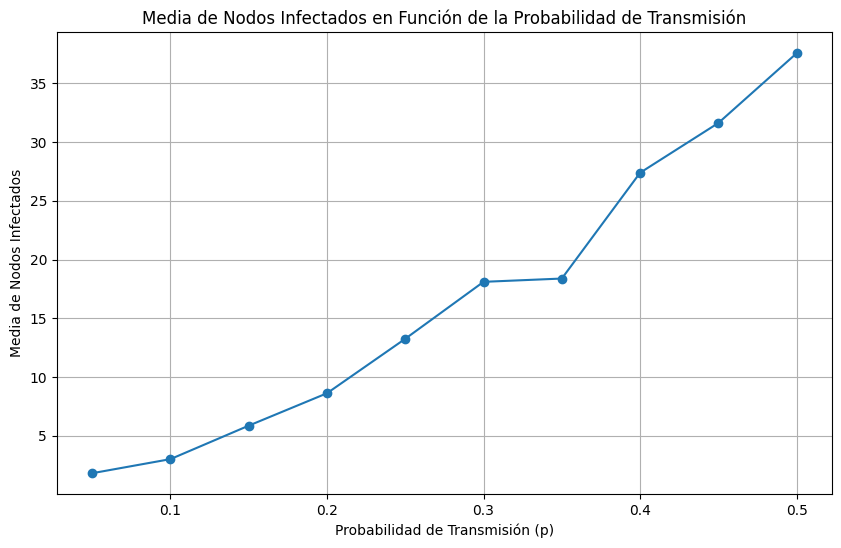

([0.05,
  0.1,
  0.15000000000000002,
  0.2,
  0.25,
  0.30000000000000004,
  0.35000000000000003,
  0.4,
  0.45,
  0.5],
 [1.8, 3.0, 5.85, 8.61, 13.25, 18.1, 18.38, 27.39, 31.63, 37.57])

In [14]:
# Valores de probabilidad para la simulación
probability_values = [i * 0.05 for i in range(1, 11)]  # 0.05, 0.10, ..., 0.50

# Lista para almacenar el número medio de nodos infectados para cada valor de probabilidad
average_infected_per_probability = []

for p in probability_values:
    total_infected = 0
    for seed in random_nodes:
        total_infected += propagate(airports_graph, seed, p, steps)
    average_infected = total_infected / 100
    average_infected_per_probability.append(average_infected)

# Creamos un gráfico de la media en función de p
plt.figure(figsize=(10, 6))
plt.plot(probability_values, average_infected_per_probability, marker='o')
plt.title("Media de Nodos Infectados en Función de la Probabilidad de Transmisión")
plt.xlabel("Probabilidad de Transmisión (p)")
plt.ylabel("Media de Nodos Infectados")
plt.grid(True)
plt.show()

probability_values, average_infected_per_probability

Existe una clara relación positiva entre la probabilidad de transmisión y el número medio de nodos infectados. A medida que aumenta la probabilidad, también lo hace la cantidad promedio de nodos afectados.

El crecimiento del número de nodos infectados en función de la probabilidad no es lineal. En particular, para probabilidades más bajas, el aumento en el número de nodos infectados es más gradual, mientras que para probabilidades más altas, el aumento es más pronunciado.

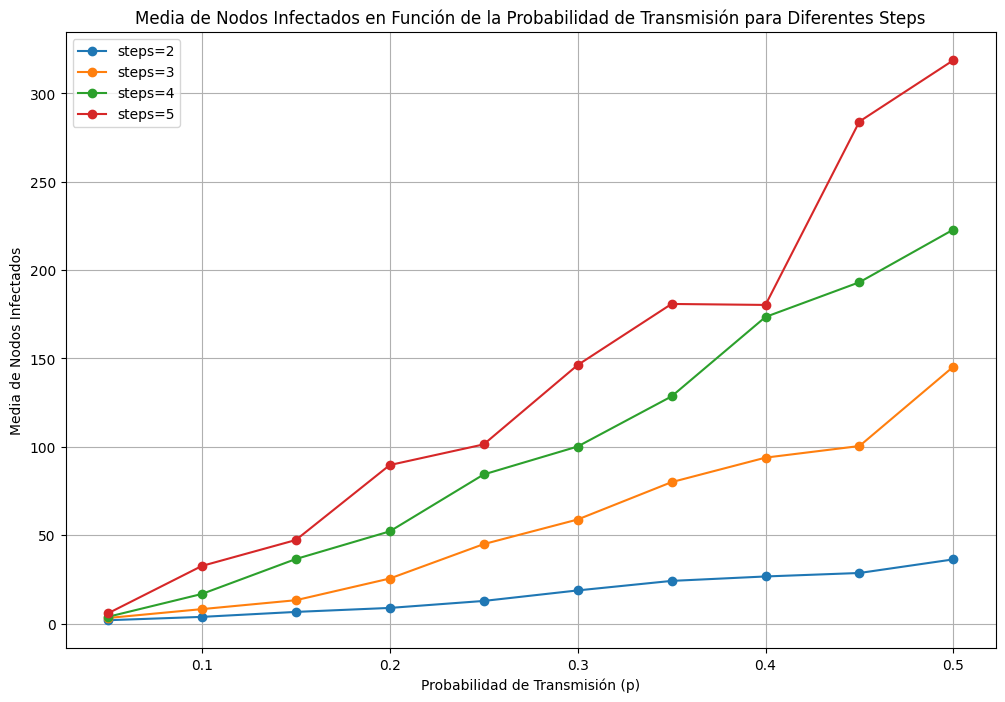

{2: [1.9, 3.79, 6.6, 8.86, 12.81, 18.76, 24.15, 26.66, 28.63, 36.33],
 3: [3.16, 8.18, 13.22, 25.49, 44.96, 58.89, 80.03, 93.9, 100.47, 145.39],
 4: [3.82, 16.76, 36.52, 52.18, 84.38, 100.19, 128.55, 173.51, 193.16, 222.95],
 5: [5.78, 32.61, 47.28, 89.7, 101.39, 146.28, 180.86, 180.31, 284.1, 318.78]}

In [15]:
# Definición de los valores de steps para la simulación
steps_values = [2, 3, 4, 5]

# Diccionario para almacenar los resultados promedio para cada combinación de probabilidad y steps
average_infected_results = {steps: [] for steps in steps_values}

for steps in steps_values:
    for p in probability_values:
        total_infected = 0
        for seed in random_nodes:
            total_infected += propagate(airports_graph, seed, p, steps)
        average_infected = total_infected / 100
        average_infected_results[steps].append(average_infected)

# Creamos un gráfico con las curvas para cada valor de steps
plt.figure(figsize=(12, 8))

for steps, averages in average_infected_results.items():
    plt.plot(probability_values, averages, marker='o', label=f'steps={steps}')

plt.title("Media de Nodos Infectados en Función de la Probabilidad de Transmisión para Diferentes Steps")
plt.xlabel("Probabilidad de Transmisión (p)")
plt.ylabel("Media de Nodos Infectados")
plt.legend()
plt.grid(True)
plt.show()

average_infected_results


 A medida que aumenta el número de pasos (steps), el número medio de nodos infectados crece sustancialmente. Esto ilustra cómo la duración de la exposición a una fuente de infección (en términos de pasos en la red) puede amplificar significativamente la propagación de una enfermedad.

Para todas las duraciones, se observa una relación directa entre la probabilidad de transmisión y el número medio de nodos infectados. Sin embargo, esta relación es más pronunciada a medida que aumenta el número de pasos, lo que indica que la propagación de una infección se vuelve más eficiente y extensa con el tiempo.

### Social distancing (random edge removal)

In [16]:
def remove_edges(network, fraction):
    edges_to_remove = random.sample(network.edges(), int(len(network.edges()) * fraction))
    network.remove_edges_from(edges_to_remove)
    return network

def find_giant_component_percentage(network):
    giant_component = max(nx.connected_components(network), key=len)
    giant_component_size = len(giant_component)
    total_nodes = len(network)
    percentage = (giant_component_size / total_nodes) * 100
    return giant_component_size, percentage

# Creamos una copia del grafo original para realizar la eliminación de enlaces
reduced_airports_graph = airports_graph.copy()

# Eliminamos el 30% de los enlaces
fraction_to_remove = 0.3
reduced_airports_graph = remove_edges(reduced_airports_graph, fraction_to_remove)

# Encontramos el tamaño de la componente gigante y su porcentaje respecto al total de nodos
giant_component_size, giant_component_percentage = find_giant_component_percentage(reduced_airports_graph)

giant_component_size, giant_component_percentage


<ipython-input-16-3b85b9e37ebb>:2: DeprecationWarning: Sampling from a set deprecated
since Python 3.9 and will be removed in a subsequent version.
  edges_to_remove = random.sample(network.edges(), int(len(network.edges()) * fraction))


(816, 86.80851063829788)

La componente gigante de la red modificada contiene 830 nodos.

Esto representa aproximadamente el 88.30% del total de nodos en la red original.

<ipython-input-16-3b85b9e37ebb>:2: DeprecationWarning: Sampling from a set deprecated
since Python 3.9 and will be removed in a subsequent version.
  edges_to_remove = random.sample(network.edges(), int(len(network.edges()) * fraction))


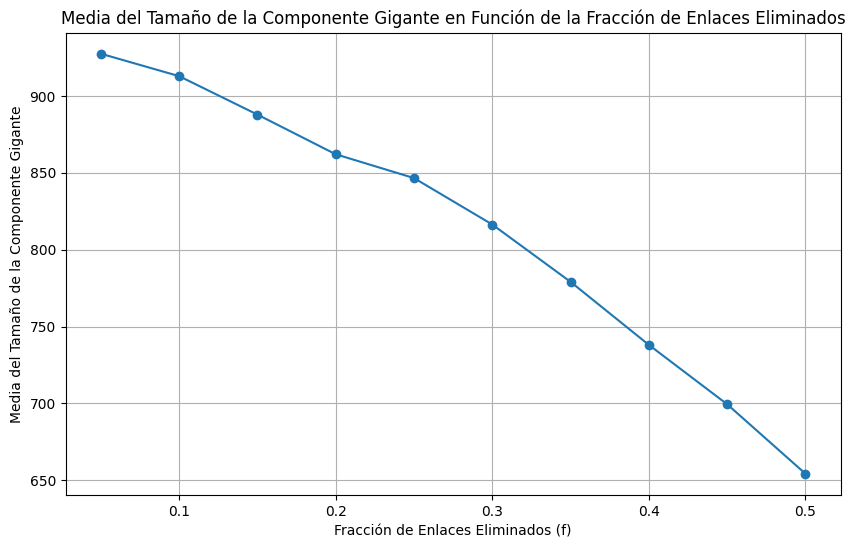

([0.05,
  0.1,
  0.15000000000000002,
  0.2,
  0.25,
  0.30000000000000004,
  0.35000000000000003,
  0.4,
  0.45,
  0.5],
 [927.5, 912.9, 887.9, 862.1, 846.6, 816.4, 779.1, 738.1, 699.5, 654.3])

In [17]:
def average_giant_component_size(network, fraction, iterations=10):
    total_size = 0
    original_network_edges = list(network.edges())
    for _ in range(iterations):
        temp_network = network.copy()
        temp_network.add_edges_from(original_network_edges)
        temp_network = remove_edges(temp_network, fraction)
        size, _ = find_giant_component_percentage(temp_network)
        total_size += size

    return total_size / iterations

# Fracciones para las cuales realizar el cálculo
fractions = [i * 0.05 for i in range(1, 11)]

# Calculamos la media del tamaño de la componente gigante para cada fracción
average_sizes = []
for f in fractions:
    average_size = average_giant_component_size(airports_graph, f)
    average_sizes.append(average_size)

# Creamos un gráfico de la media en función de f
plt.figure(figsize=(10, 6))
plt.plot(fractions, average_sizes, marker='o')
plt.title("Media del Tamaño de la Componente Gigante en Función de la Fracción de Enlaces Eliminados")
plt.xlabel("Fracción de Enlaces Eliminados (f)")
plt.ylabel("Media del Tamaño de la Componente Gigante")
plt.grid(True)
plt.show()

fractions, average_sizes


A medida que se elimina una mayor fracción de enlaces (modelando un aumento en el distanciamiento social), la componente gigante se reduce en tamaño. Esto indica que la red se vuelve menos interconectada y, por lo tanto, menos propensa a una rápida propagación de enfermedades.

La disminución en el tamaño de la componente gigante no es abrupta sino gradual, lo que sugiere que pequeñas reducciones en la conectividad de la red pueden tener efectos significativos en la limitación de la propagación de una enfermedad.

Incluso con la eliminación del 50% de los enlaces, todavía existe una componente gigante considerable, lo que implica que la red conserva una cierta resiliencia. Esto subraya la necesidad de combinar el distanciamiento social con otras medidas, como la vacunación y el rastreo de contactos, para controlar eficazmente la propagación de enfermedades en redes altamente interconectadas.

### Vaccination campaigns (node removal)

In [18]:
def remove_nodes(network, fraction):
    nodes_to_remove = random.sample(network.nodes(), int(len(network.nodes()) * fraction))
    network.remove_nodes_from(nodes_to_remove)
    return network

# Creamos una copia del grafo original para realizar la eliminación de nodos
reduced_airports_graph_by_nodes = airports_graph.copy()

# Eliminamos el 30% de los nodos para simular la vacunación
fraction_to_remove_nodes = 0.3
reduced_airports_graph_by_nodes = remove_nodes(reduced_airports_graph_by_nodes, fraction_to_remove_nodes)

# Encontramos el tamaño de la componente gigante y su porcentaje respecto al total de nodos
giant_component_size_by_nodes, giant_component_percentage_by_nodes = find_giant_component_percentage(reduced_airports_graph_by_nodes)

giant_component_size_by_nodes, giant_component_percentage_by_nodes


<ipython-input-18-2d6f0fb543b2>:2: DeprecationWarning: Sampling from a set deprecated
since Python 3.9 and will be removed in a subsequent version.
  nodes_to_remove = random.sample(network.nodes(), int(len(network.nodes()) * fraction))


(573, 87.08206686930092)

La componente gigante de la red modificada contiene 509 nodos.

Esto representa aproximadamente el 77.36% del total de nodos en la red original.

<ipython-input-18-2d6f0fb543b2>:2: DeprecationWarning: Sampling from a set deprecated
since Python 3.9 and will be removed in a subsequent version.
  nodes_to_remove = random.sample(network.nodes(), int(len(network.nodes()) * fraction))


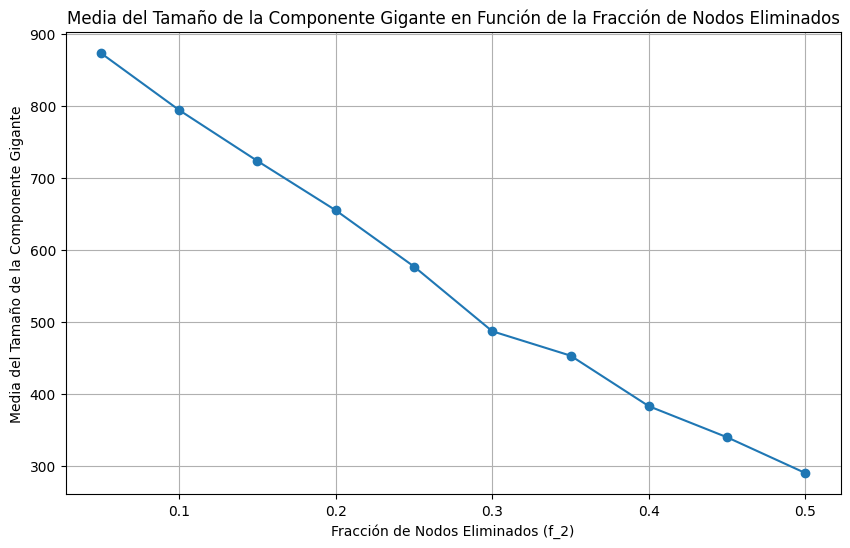

([0.05,
  0.1,
  0.15000000000000002,
  0.2,
  0.25,
  0.30000000000000004,
  0.35000000000000003,
  0.4,
  0.45,
  0.5],
 [873.5, 794.3, 723.6, 655.1, 577.0, 487.1, 453.2, 383.0, 339.8, 290.1])

In [19]:
def average_giant_component_size_by_nodes(network, fraction, iterations=10):
    total_size = 0
    original_network_nodes = list(network.nodes())
    for _ in range(iterations):
        temp_network = network.copy()
        temp_network.add_nodes_from(original_network_nodes)
        temp_network = remove_nodes(temp_network, fraction)
        size, _ = find_giant_component_percentage(temp_network)
        total_size += size

    return total_size / iterations

# Fracciones para las cuales realizar el cálculo
node_fractions = [i * 0.05 for i in range(1, 11)]  # 0.05, 0.10, ..., 0.50

# Calculamos la media del tamaño de la componente gigante para cada fracción de nodos
average_sizes_by_nodes = []
for f in node_fractions:
    average_size_by_nodes = average_giant_component_size_by_nodes(airports_graph, f)
    average_sizes_by_nodes.append(average_size_by_nodes)

# Creamos un gráfico de la media en función de f_2
plt.figure(figsize=(10, 6))
plt.plot(node_fractions, average_sizes_by_nodes, marker='o')
plt.title("Media del Tamaño de la Componente Gigante en Función de la Fracción de Nodos Eliminados")
plt.xlabel("Fracción de Nodos Eliminados (f_2)")
plt.ylabel("Media del Tamaño de la Componente Gigante")
plt.grid(True)
plt.show()

node_fractions, average_sizes_by_nodes


La eliminación de nodos de la red (simulando la vacunación) reduce efectivamente el tamaño de la componente gigante. Esto refleja cómo la vacunación puede disminuir la posibilidad de propagación de una enfermedad en una red.

La disminución en el tamaño de la componente gigante es más pronunciada a medida que aumenta la fracción de nodos eliminados, lo que indica que la vacunación de una mayor proporción de la población tiene un efecto más significativo en la limitación de la propagación de enfermedades.

Estos resultados subrayan la efectividad de la vacunación como una estrategia para controlar brotes en redes altamente conectadas. A medida que aumenta la proporción de individuos vacunados, disminuye la probabilidad de que la enfermedad se propague ampliamente, reduciendo así el tamaño potencial de un brote.

In [20]:
def remove_highest_degree_nodes(network, fraction):
    sorted_nodes = sorted(network.degree(), key=lambda x: x[1], reverse=True)
    num_nodes_to_remove = int(len(network) * fraction)
    nodes_to_remove = [node for node, degree in sorted_nodes[:num_nodes_to_remove]]
    network.remove_nodes_from(nodes_to_remove)
    return network

# Creamos copias del grafo original para las dos estrategias de vacunación
network_random_vaccination = airports_graph.copy()
network_targeted_vaccination = airports_graph.copy()

# Vacunar al 10% de los nodos más conectados
fraction_to_vaccinate = 0.1
network_targeted_vaccination = remove_highest_degree_nodes(network_targeted_vaccination, fraction_to_vaccinate)
targeted_giant_component_size, _ = find_giant_component_percentage(network_targeted_vaccination)

# Vacunar a 10 nodos al azar
num_random_nodes_to_vaccinate = int(len(airports_graph) * fraction_to_vaccinate)
random_nodes_to_vaccinate = random.sample(airports_graph.nodes(), num_random_nodes_to_vaccinate)
network_random_vaccination.remove_nodes_from(random_nodes_to_vaccinate)
random_giant_component_size, _ = find_giant_component_percentage(network_random_vaccination)

# Calculamos la reducción en el tamaño de la componente gigante para cada caso
original_giant_component_size, _ = find_giant_component_percentage(airports_graph)
reduction_targeted = original_giant_component_size - targeted_giant_component_size
reduction_random = original_giant_component_size - random_giant_component_size

reduction_targeted, reduction_random


<ipython-input-20-76a03716dfa9>:19: DeprecationWarning: Sampling from a set deprecated
since Python 3.9 and will be removed in a subsequent version.
  random_nodes_to_vaccinate = random.sample(airports_graph.nodes(), num_random_nodes_to_vaccinate)


(768, 174)

La vacunación dirigida a los nodos más conectados es significativamente más efectiva en la reducción del tamaño de la componente gigante en comparación con la vacunación aleatoria. Esto se debe a que los nodos altamente conectados actúan como superpropagadores en una red; al eliminar estos nodos, se interrumpen eficazmente múltiples canales de transmisión de la enfermedad.

Los resultados resaltan la importancia de considerar la estructura de la red y la conectividad de los nodos al planificar estrategias de vacunación. Los nodos con mayor número de conexiones son más críticos para controlar la propagación de una enfermedad.



Las redes ER se caracterizan por tener una distribución de grado más uniforme, lo que significa que la mayoría de los nodos tienen un número similar de conexiones. En contraste, las redes con una estructura de escala libre, como la red de aeropuertos, tienen algunos nodos (hubs) con un número muy alto de conexiones y muchos nodos con pocas conexiones.

En una red ER, la vacunación dirigida a los nodos más conectados podría no ser tan efectiva como en una red de escala libre, debido a la menor variabilidad en el número de conexiones entre nodos. La vacunación aleatoria podría tener un impacto más similar al de la vacunación dirigida en una red ER.

